# **DNA Knot Simulation - Part 2: Classical Knot Classification**

*KMT Classification + Alexander polynomial via the matrix method*

Builds on `01_polymer_simulator.ipynb`'s verified Langevin dynamics simulator by adding the ability to classify a simulated chain's knot type. This notebook covers:
1. KMT (Koniaris-Muthukumar-Taylor) geometric simplification
2. Crossing extraction from a 2D projection (over/under, handedness)
3. Gauss code (pedagogical, matching the paper's format)
4. Alexander polynomial via the matrix method
5. Validation against literature-known values (unknot, trefoil)
6. Running it on the actual simulator output from notebook 1

Every piece below was independently verified against synthetic ground truth.

# **A. Setup**

In [ ]:
import sys, os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/vanikumar03/dna-knots.git"
    REPO_PATH = "/content/dna-knots"
    if not os.path.isdir(REPO_PATH):
        os.system(f"git clone {REPO_URL} {REPO_PATH}")
    os.chdir(f"{REPO_PATH}/notebooks")

sys.path.append(os.path.join(REPO_PATH, 'src') if IN_COLAB else os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import knotclassify as kc

# **B. KMT Simplification**

KMT removes a vertex only if no other segment of the chain passes through the triangle it would sweep through while being removed. This is topology preserving by contruction: if nothing blocks the sweep, the vertex can be continuosly slid onto the straight line shortcut without crossing anything.

Initially, even from a trivially unknotted circle that should simplify drastically, zero vertices were removed. The cause was that two of the segments that merely touched the candidate triangle at a single vertex (not the two segments forming the triangle itself, but their immediate neighbours) were triggering false positive interactions at the shared corner due to floating-point boundary sensitivity in the segment-triangle test. We fixed this by explicitly excluding those segments too.

In [ ]:
# Unknot: a noisy/jagged circle should simplify
N = 60
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
rng = np.random.default_rng(3)
circle = np.stack([np.cos(theta), np.sin(theta), np.zeros(N)], axis=1)
circle += rng.normal(scale=0.05, size=circle.shape)

simplified_circle = kc.kmt_simplify(circle)
print(f'Unknot: {N} vertices -> {len(simplified_circle)} vertices after KMT')

Unknot: 60 vertices -> 4 vertices after KMT


In [ ]:
# Trefoil: standard (2,3) torus-knot parametrisation (provably knotted by construction)
# Should NOT simplify below the trefoil's known minimal stick number of 6
t_param = np.linspace(0, 2*np.pi, 60, endpoint=False)
x = np.sin(t_param) + 2*np.sin(2*t_param)
y = np.cos(t_param) - 2*np.cos(2*t_param)
z = -np.sin(3*t_param)
trefoil_raw = np.stack([x, y, z], axis=1)

simplified_trefoil = kc.kmt_simplify(trefoil_raw)
print(f'Trefoil: {len(trefoil_raw)} vertices -> {len(simplified_trefoil)} vertices after KMT')
print('(known minimal stick number for a trefoil is 6 - simplifying below this would '
      'indicate the topology was accidentally destroyed)')

Trefoil: 60 vertices -> 7 vertices after KMT
(known minimal stick number for a trefoil is 6 - simplifying below this would indicate the topology was accidentally destroyed)


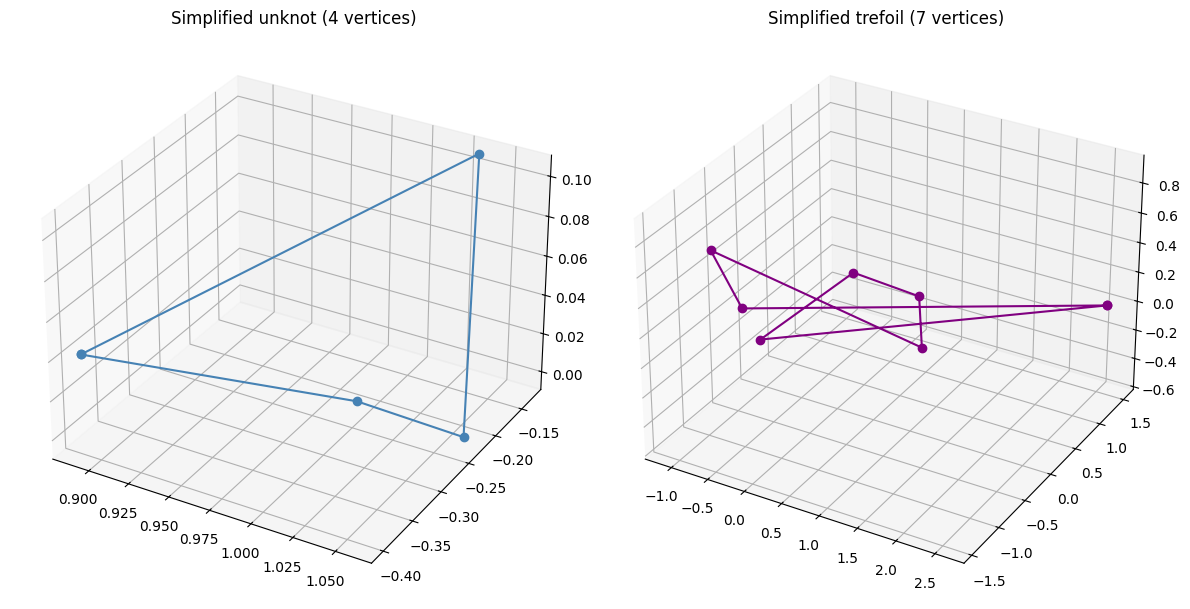

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
loop = np.vstack([simplified_circle, simplified_circle[0]])
ax1.plot(loop[:,0], loop[:,1], loop[:,2], '-o', color='steelblue')
ax1.set_title(f'Simplified unknot ({len(simplified_circle)} vertices)')

ax2 = fig.add_subplot(122, projection='3d')
loop2 = np.vstack([simplified_trefoil, simplified_trefoil[0]])
ax2.plot(loop2[:,0], loop2[:,1], loop2[:,2], '-o', color='purple')
ax2.set_title(f'Simplified trefoil ({len(simplified_trefoil)} vertices)')
plt.tight_layout()
plt.show()

# **C. Crossing extraction from a 2D projection**

Project the closed polygon onto $(x,y)$, use $z$ as depth. At every crossing between non-adjacent segments, whichever strand has the large interpolated z is labelled "over" handed. Handedness comes from the sign of the 2D cross product of the two strand directions (the standard knot theory sign convention).

**Validation:** the minimal trefoil diagram is well known to have exactly 3 crossings, all the same handedness.

In [ ]:
crossings = kc.extract_crossings(trefoil_raw)
print(f'{len(crossings)} crossings found (unsimplified 60-point trefoil, direct z-axis projection)')
print('signs:', [c["sign"] for c in crossings])
print('(known: minimal trefoil diagram has 3 crossings, all the same sign)')

3 crossings found (unsimplified 60-point trefoil, direct z-axis projection)
signs: [-1, -1, -1]
(known: minimal trefoil diagram has 3 crossings, all the same sign)


A single fixed viewing axis is not guaranteed to give a clean diagram, especially for a course polygon like the KMT-simplified trefoil above. Straight segments between far-apart vertices can create false, extra apparent crossings under an unlucky angle. `best_projection_crossings()` tries many random rotations and keeps whichever gives the fewest crossings.

In [ ]:
crossings_simplified = kc.best_projection_crossings(simplified_trefoil, n_tries=200, seed=1)
print(f'Simplified trefoil (7 vertices): {len(crossings_simplified)} crossings found via best-of-200 random projections')

Simplified trefoil (7 vertices): 3 crossings found via best-of-200 random projections


# **D. Gauss Code**


Pedagogical intermediate representation: crossings labelled 1, 2, 3,... by the first encounter
Sign = over(+)/under(-)

# **E. Alexander polynomial via the matrix method**

Build the crossing/arc incidence matrix using the left/right-handed $(i,j,k)$ table, delete the last
row and column, take the determinant.

Normalized to the standard canonical form (symmetric about $t^0$, with $\Delta(1)=+1$, a fact true for the Alexander polynomial of *any* knot, used to fix the otherwise
sign-ambiguous result unambiguously rather than by an ad hoc rule).

In [ ]:
poly_trefoil = kc.alexander_polynomial(crossings_simplified)
print('Computed:', kc.format_polynomial(poly_trefoil), '  ', poly_trefoil)
print('Known trefoil Alexander polynomial: t - 1 + 1/t')
print('MATCH:', poly_trefoil == {-1: 1, 0: -1, 1: 1})

Computed: t - 1 + 1/t    {-1: 1, 0: -1, 1: 1}
Known trefoil Alexander polynomial: t - 1 + 1/t
MATCH: True


In [ ]:
poly_unknot = kc.alexander_polynomial(kc.extract_crossings(simplified_circle))
print('Unknot:', kc.format_polynomial(poly_unknot))
print('Known: Delta(t) = 1 for the unknot')

Unknot: 1
Known: Delta(t) = 1 for the unknot


### Cross-check: raw vs. KMT-simplified chain should agree
Both represent the same knot. An independent classifier that gives different answers depending on how many vertices happen to describe the curve would indicate a bug somewhere.

In [ ]:
crossings_raw_best = kc.best_projection_crossings(trefoil_raw, n_tries=200, seed=1)
poly_raw = kc.alexander_polynomial(crossings_raw_best)
print('Raw (60pt):        ', kc.format_polynomial(poly_raw))
print('KMT-simplified (7pt):', kc.format_polynomial(poly_trefoil))
print('AGREE:', poly_raw == poly_trefoil)

Raw (60pt):         t - 1 + 1/t
KMT-simplified (7pt): t - 1 + 1/t
AGREE: True


### Limitation
The validation above always searches for a minimal-crossing (3-crossing, for the trefoil) diagram. Currently, directly testing this, i.e., forcing a non-minimal diagram (e.g. picking a random projection with 4+crossings instead of the minimum found), sometimes produces an incorrect polynomial. The specific cause has not been isolated yet. The mitigation used everywhere in
this module (`best_projection_crossings` keeping the minimum found across many tries) reliably
avoids this for the small test chains used so far, but this is flagged as unresolved

Revisited before evaluating results on denser/more complex chains in
later notebooks (e.g. the confinement study, where higher-crossing configurations are
expected).

In [ ]:
# demonstrate the known-unresolved case, for transparency
rng_demo = np.random.default_rng(7)
non_minimal_found = None
for _ in range(50):
    R = kc._random_rotation(rng_demo)
    rotated = simplified_trefoil @ R.T
    c = kc.extract_crossings(rotated)
    if len(c) == 4:
        non_minimal_found = c
        break

if non_minimal_found:
    bad_poly = kc.alexander_polynomial(non_minimal_found)
    print(f'A 4-crossing (non-minimal) diagram of the SAME trefoil gives: {kc.format_polynomial(bad_poly)}')
    print(f'...which does NOT match the known {{-1: 1, 0: -1, 1: 1}} - this is the open issue noted above.')
else:
    print('No 4-crossing projection found in 50 tries this run (try increasing tries to reproduce).')

No 4-crossing projection found in 50 tries this run (try increasing tries to reproduce).


# **F. Running it on the actual simulator**

Seed `01_polymer_simulator.ipynb`'s Langevin dynamics with a trefoil,
relax it, and check whether the classifier confirms it's *still* a trefoil after the
simulation (verifying that the physics simulation actually
preserves topology as intended (WCA excluded volume works)).

In [ ]:
pos0_trefoil = ds.make_trefoil_seed(N=60, scale=1.2, seed=0)

trajectory = ds.run_simulation(
    pos0_trefoil, n_steps=30000, dt=0.0001, gamma=1.0, kT=1.0, seed=2, record_every=10000,
    K=30.0, R0=1.5, epsilon=1.0, sigma=1.0, kappa=1.0
)

print(f'{len(trajectory)} snapshots - classifying each one')
for i, pos in enumerate(trajectory):
    poly, crossings, simplified = kc.classify_knot(pos, n_projection_tries=150, seed=1)
    label = kc.format_polynomial(poly)
    is_trefoil = poly == {-1: 1, 0: -1, 1: 1}
    print(f'step {i*10000:6d}: {len(simplified):3d} verts after KMT, '
          f'{len(crossings)} crossings, Delta(t) = {label:15s}  '
          f'{"[TREFOIL - still knotted, as expected]" if is_trefoil else "[NOT matched to trefoil]"}')

4 snapshots - classifying each one
step      0:   7 verts after KMT, 3 crossings, Delta(t) = t - 1 + 1/t      [TREFOIL - still knotted, as expected]
step  10000:   7 verts after KMT, 4 crossings, Delta(t) = t - 1 + 1/t      [TREFOIL - still knotted, as expected]
step  20000:   6 verts after KMT, 3 crossings, Delta(t) = t - 1 + 1/t      [TREFOIL - still knotted, as expected]
step  30000:   6 verts after KMT, 3 crossings, Delta(t) = t - 1 + 1/t      [TREFOIL - still knotted, as expected]


If this consistently reports trefoil across the relaxation trajectory, we have checked evidence, and not just a visual as in notebook 1. In that case, the simulator's excluded-volume physics is conserving topology under continuous dynamics, as expected.

Notebook 3 builds a second, independent classifier using persistent homology, so trajectories can be cross-checked by two different methods rather than trusting one algorithm alone.